# Gradient Ascent — CS 175 Final Report Experiments
**Team:** Priya Deshmukh, Davin Makris, Amish Kunal

This notebook loads pretrained checkpoints and reproduces all figures and results from the final report.
All models are loaded from saved checkpoints so the notebook runs in under 1 minute.

In [69]:
import sys
from pathlib import Path
import copy
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from monkeys.LoRAMonkey import LoRAMonkey, LoRALinear

# set up repo root for imports, replace with own path
REPO_ROOT = Path("/Users/priyasd/Desktop/cs-175-project/cs-175").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from classifier.transformer_judge import TransformerJudge
from monkeys.TransformerMonkey import TransformerMonkey, CharTokenizer
from monkeys.bigram import BigramModel
from monkeys.generator import random_monkey
from classifier.judge import Noise_Shakespeare_Classifier
from utils.load_datasets import load_shakespeare_dataset, load_old_english_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [72]:
import os
# replace with own path
os.chdir("/Users/priyasd/Desktop/cs-175-project/cs-175")
print(os.getcwd())  # confirm it worked

/Users/priyasd/Desktop/cs-175-project/cs-175


In [73]:
from pathlib import Path
for f in Path("models").iterdir():
    print(f.name)

LoRA.pt
oe_then_shakespeare.pt
SmallTransformerMonkey2.pt
experiments1
best_evolved_lm_head.pt
SmallTransformerMonkey.pt
transformer_judge.pt


## 1. Load Checkpoints

In [82]:
JUDGE_CKPT = Path("models/transformer_judge.pt")
EVOLVED_CKPT = Path("models/best_evolved_lm_head.pt")
FINETUNED_CKPT = Path("models/oe_then_shakespeare.pt")
LORA_CKPT = Path("models/LoRA.pt")
NOISE_FILE = "noise_dataset/noise.txt"

# Load transformer judge
try:
    ckpt = torch.load(JUDGE_CKPT, map_location=device, weights_only=False)
except TypeError:
    ckpt = torch.load(JUDGE_CKPT, map_location=device)

tokenizer = ckpt["tokenizer"]
cfg = ckpt["base_model_config"]

base_model = TransformerMonkey(
    tokenizer.vocab_size, tokenizer=tokenizer,
    block_size=int(cfg["block_size"]), n_embd=int(cfg["n_embd"]),
    n_head=int(cfg["n_head"]),        n_layer=int(cfg["n_layer"]),
    dropout=float(cfg["dropout"]),
).to(device)

judge = TransformerJudge(base_model).to(device)
judge.load_state_dict(ckpt["judge_state_dict"])
judge.eval()
print("Transformer judge loaded")

# Load TF-IDF judge 
tfidf = Noise_Shakespeare_Classifier()
tfidf.train(NOISE_FILE, show_report=False)
print("TF-IDF judge loaded")

# Load finetuned model (Transformer trained on OE and finetuned on Shakespeare)
try:
    ft_ckpt = torch.load(FINETUNED_CKPT, map_location=device, weights_only=False)
except TypeError:
    ft_ckpt = torch.load(FINETUNED_CKPT, map_location=device)

ft_model = TransformerMonkey(
    tokenizer.vocab_size, tokenizer=tokenizer,
    block_size=int(cfg["block_size"]), n_embd=int(cfg["n_embd"]),
    n_head=int(cfg["n_head"]),        n_layer=int(cfg["n_layer"]),
    dropout=float(cfg["dropout"]),
).to(device)
ft_model.load_state_dict(ft_ckpt["model_state_dict"])
ft_model.eval()
print("Finetuned model loaded")

# Load evolved model 
evolved_model = copy.deepcopy(judge.transformer)
ev_ckpt = torch.load(EVOLVED_CKPT, map_location=device)
evolved_model.lm_head.load_state_dict(ev_ckpt["lm_head"])
evolved_model.eval()
print("Evolved model loaded")

# Load LoRA monkey
sys.path.insert(0, "monkeys")  
# rebuild base monkey 
lora_base = TransformerMonkey(
    85,
    tokenizer=tokenizer, # loading lora tokenizer seperately
    block_size=256,
    n_embd=128,
    n_head=16,
    n_layer=12,
    dropout=0.4
).to(device)

lora_model = LoRAMonkey(lora_base, rank=16, alpha=2).to(device)
lora_ckpt = torch.load("models/LoRA.pt", map_location=device, weights_only=False)
lora_model.lm_head = LoRALinear(lora_model.lm_head, rank=16, alpha=2).to(device)
lora_model.load_state_dict(lora_ckpt)
lora_model.eval()
# LoRA model uses different tokenizer
lora_tokenizer = CharTokenizer.loadTokenizer(Path("tokenizers/oldEnglishCharTokenizer.pkl"))

print("LoRA model and tokenizer loaded")

Transformer judge loaded
fitting vectorizer
training logistic regression
TF-IDF judge loaded
Finetuned model loaded
Evolved model loaded
LoRA model and tokenizer loaded


## 2. Helper Functions

In [76]:
def score_text(text, judge, tokenizer, device):
    ids = tokenizer.encode(text) or [0]
    block = int(judge.transformer.block_size)
    ids = ids[-block:]
    x = torch.tensor([ids], dtype=torch.long, device=device)
    lengths = torch.tensor([len(ids)], dtype=torch.long, device=device)
    with torch.no_grad():
        return judge(x, lengths=lengths, pad_id=0).item()

def generate(model, tokenizer, prompt, device, max_new_tokens=200):
    ids = tokenizer.encode(prompt) or [0]
    x = torch.tensor([ids], dtype=torch.long, device=device)
    with torch.no_grad():
        y = model.generate(x, max_new_tokens=max_new_tokens)
    return tokenizer.decode(y[0].tolist())

def score_texts(texts, judge, tokenizer, device):
    return [score_text(t, judge, tokenizer, device) for t in texts]


## 3. Figure 1 — Judge Score Distributions by Text Source

Repo card metadata block was not found. Setting CardData to empty.


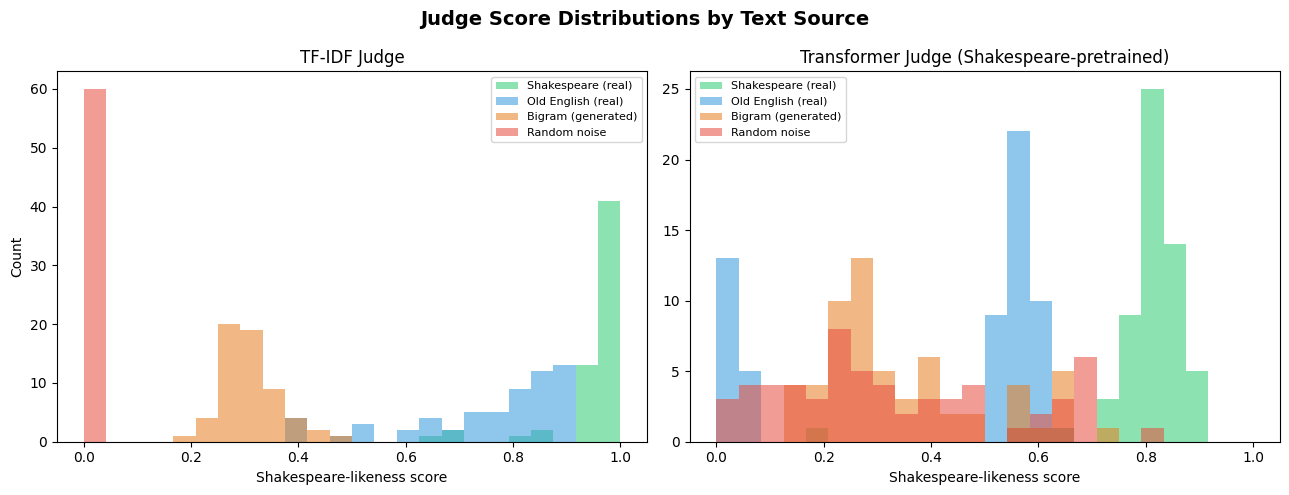

Saved: results/judge_score_distributions.png


In [77]:
N_SAMPLES = 60
SAMPLE_LEN = 300

sp = list(load_shakespeare_dataset(0.0, 0.0))
oe = list(load_old_english_dataset(0.0, 0.0))
bigram = BigramModel(smoothing=0.5).fit([str(x) for x in sp[:2000]])

categories = {
    "Shakespeare (real)":  [str(x) for x in sp[:N_SAMPLES]],
    "Old English (real)":  [str(x) for x in oe[:N_SAMPLES]],
    "Bigram (generated)": [bigram.generate(SAMPLE_LEN, seed=i) for i in range(N_SAMPLES)],
    "Random noise":        [random_monkey(SAMPLE_LEN) for _ in range(N_SAMPLES)],
}

tfidf_scores = {k: list(tfidf.shakespeare_likeliness(v)) for k, v in categories.items()}
tr_scores    = {k: score_texts(v, judge, tokenizer, device) for k, v in categories.items()}

COLORS = {
    "Shakespeare (real)": "#2ecc71",
    "Old English (real)": "#3498db",
    "Bigram (generated)": "#e67e22",
    "Random noise":        "#e74c3c",
}

bins = np.linspace(0, 1, 25)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Judge Score Distributions by Text Source", fontsize=14, fontweight="bold")

for cat, scores in tfidf_scores.items():
    axes[0].hist(scores, bins=bins, alpha=0.55, color=COLORS[cat], label=cat)
axes[0].set_title("TF-IDF Judge")
axes[0].set_xlabel("Shakespeare-likeness score")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

for cat, scores in tr_scores.items():
    axes[1].hist(scores, bins=bins, alpha=0.55, color=COLORS[cat], label=cat)
axes[1].set_title("Transformer Judge (Shakespeare-pretrained)")
axes[1].set_xlabel("Shakespeare-likeness score")
axes[1].legend(fontsize=8)

plt.tight_layout()
Path("results").mkdir(exist_ok=True)
plt.savefig("results/judge_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/judge_score_distributions.png")

## 4. Figure 2 — Method Comparison Bar Chart

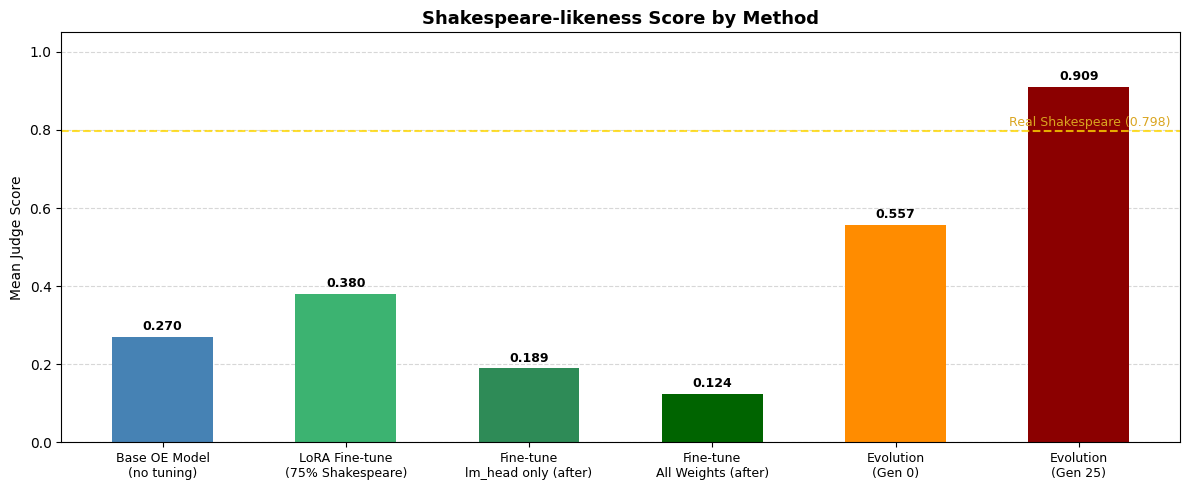

Saved: results/method_comparison.png


In [78]:
methods = [
    "Base OE Model\n(no tuning)",
    "LoRA Fine-tune\n(75% Shakespeare)",
    "Fine-tune\nlm_head only (after)",
    "Fine-tune\nAll Weights (after)",
    "Evolution\n(Gen 0)",
    "Evolution\n(Gen 25)",
]
means = [0.27, 0.38, 0.189, 0.124, 0.557, 0.909]
colors = ['steelblue', 'mediumseagreen', 'seagreen', 'darkgreen', 'darkorange', 'darkred']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(methods))
bars = ax.bar(x, means, color=colors, width=0.55)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.01,
            f"{mean:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(y=0.798, color="gold", linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(len(methods)-0.5, 0.81, "Real Shakespeare (0.798)", color="goldenrod", fontsize=9, ha="right")

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=9)
ax.set_ylabel("Mean Judge Score")
ax.set_ylim(0, 1.05)
ax.set_title("Shakespeare-likeness Score by Method", fontsize=13, fontweight="bold")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("results/method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/method_comparison.png")

## 5. Figure 3 — Evolution Score Progression

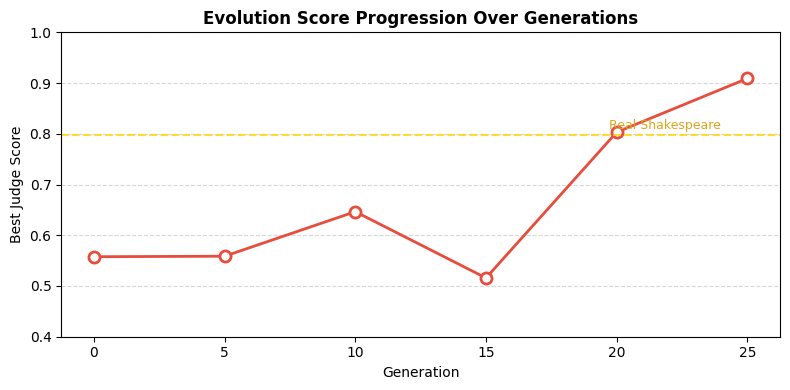

Saved: results/evolution_progression.png


In [79]:
# Scores recorded from terminal output during evolution run
generations = [0, 5, 10, 15, 20, 25]
best_scores = [0.5577, 0.5587, 0.6465, 0.5158, 0.8031, 0.9090]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(generations, best_scores, marker="o", linewidth=2,
        color="#e74c3c", markersize=8, markerfacecolor="white", markeredgewidth=2)

ax.axhline(y=0.798, color="gold", linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(24, 0.81, "Real Shakespeare", color="goldenrod", fontsize=9, ha="right")

ax.set_xlabel("Generation")
ax.set_ylabel("Best Judge Score")
ax.set_title("Evolution Score Progression Over Generations", fontsize=12, fontweight="bold")
ax.set_ylim(0.4, 1.0)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("results/evolution_progression.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/evolution_progression.png")

## 6. Qualitative Examples — Generated Text Per Method

In [80]:
prompts = [
    "To be, or not to be ",
    "Romeo, wherefore art thou ",
]

print("=" * 70)
print("GENERATED TEXT COMPARISON")
print("=" * 70)

for prompt in prompts:
    print(f"\nPrompt: {prompt!r}")
    print("-" * 70)

    # Base model (judge's frozen transformer = OE pretrained)
    base_text = generate(judge.transformer, tokenizer, prompt, device)
    base_score = score_text(base_text, judge, tokenizer, device)
    print(f"[Base OE model]  score={base_score:.3f}")
    print(base_text[:200])
    print()

    # Finetuned model
    ft_text = generate(ft_model, tokenizer, prompt, device)
    ft_score = score_text(ft_text, judge, tokenizer, device)
    print(f"[Fine-tuned all] score={ft_score:.3f}")
    print(ft_text[:200])
    print()

    # Evolved model
    ev_text = generate(evolved_model, tokenizer, prompt, device)
    ev_score = score_text(ev_text, judge, tokenizer, device)
    print(f"[Evolved Gen 25] score={ev_score:.3f}")
    print(ev_text[:200])
    print()
    
    # LoRA model

    lora_ids = lora_tokenizer.encode(prompt) or [0]
    lora_input = torch.tensor([lora_ids], dtype=torch.long, device=device)
    
    with torch.no_grad():
        lora_output = lora_model.generate(lora_input, max_new_tokens=200)
        
    lora_text = lora_tokenizer.decode(lora_output[0].tolist())
    filtered_lora = "".join([c for c in lora_text if c in judge.transformer.tokenizer.stoi])
    lora_score = score_text(filtered_lora, judge, tokenizer, device)
    print(f"[LoRA fine-tuned] score={lora_score:.3f}")
    print(lora_text[:200])
    print()

GENERATED TEXT COMPARISON

Prompt: 'To be, or not to be '
----------------------------------------------------------------------
[Base OE model]  score=0.245
To be, or not to be sour pandy cerell sear usule,
Whe he thy the wou the oo wrd hyof he crou m shite aberd thas serdele
Ombouthe thid at nof th fe tichest th de touth noune he t
uren vehancorst owplin

[Fine-tuned all] score=0.679
To be, or not to be that and faring.

BUCENTETIO:
I the not hat shime ith so the tand son have and with to knot low of king to wit,
But haves so my sot to hish acome a in, the bood arrits to gerand.



[Evolved Gen 25] score=0.270
To be, or not to be take blesaley t inghonsll ifaves,
One iveracens ke mid bly acerrakendend I beavefeds haveflearallallens, I beavesak, thicenghine?
Noue
KERIORO:
Nond d illo; deceas beal; ansey blea

[LoRA fine-tuned] score=0.627
To be, or not to be allowed to be allow to suffer life. Therefore they could not found again that they were not bear to him, when he was the bring o

## 7. Judge Comparison Table

In [81]:
from statistics import mean

print(f"{'Source':<20} | {'TF-IDF mean':>12} | {'Transformer mean':>16} | {'Separation':>10}")
print("-" * 68)

for src, (tfidf_sc, tr_sc) in zip(
    categories.keys(),
    zip(tfidf_scores.values(), tr_scores.values())
):
    t_mean = mean(tfidf_sc)
    tr_mean = mean(tr_sc)
    # separation = distance from Shakespeare mean
    sp_tr_mean = mean(tr_scores["Shakespeare (real)"])
    sep = abs(sp_tr_mean - tr_mean)
    print(f"{src:<20} | {t_mean:>12.3f} | {tr_mean:>16.3f} | {sep:>10.3f}")

Source               |  TF-IDF mean | Transformer mean | Separation
--------------------------------------------------------------------
Shakespeare (real)   |        0.947 |            0.798 |      0.000
Old English (real)   |        0.760 |            0.408 |      0.390
Bigram (generated)   |        0.309 |            0.347 |      0.451
Random noise         |        0.013 |            0.336 |      0.462
